# EDA: London Heathrow Daily Weather

Exploratory data analysis on the ECA&D Heathrow dataset before modelling. The goal is to understand the data with the intention of later building ML models predicting the amount of daily sunshine. 

This notebook will:
- Read in a data file downloaded from ECAD.
- Explore the data & make decisions on the later cleaning process.
- Visualise the data.
- Perform a mutual information calculation.

Data from the European Climate Assessment & Dataset (ECA&D).
Permision to use data granted as long as following source is acknowledged:

 Klein Tank, A.M.G. and Coauthors, 2002. Daily dataset of 20th-century surface 
 air temperature and precipitation series for the European Climate Assessment. 
 Int. J. of Climatol., 22, 1441-1453.                                          
 Data and metadata available at http://www.ecad.eu                             


## 1. Setup

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.feature_selection import mutual_info_regression

from data import load_raw, clean
from features import add_lag_features, add_season
from plots import plot_lag_scatter, plot_cloud_cover, plot_global_radiation, plot_pressure_histogram

FIGURES = '../notebooks/figures'

df = load_raw()
df_clean = clean(df)
df.head()

,date,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,snow_depth
0,1979-01-01,2.0,7.0,52.0,2.3,-4.1,-7.5,0.4,101900.0,9.0
1,1979-01-02,6.0,1.7,27.0,1.6,-2.6,-7.5,0.0,102530.0,8.0
2,1979-01-03,5.0,0.0,13.0,1.3,-2.8,-7.2,0.0,102050.0,4.0
3,1979-01-04,8.0,0.0,13.0,-0.3,-2.6,-6.5,0.0,100840.0,2.0
4,1979-01-05,6.0,2.0,29.0,5.6,-0.8,-1.4,0.0,102250.0,1.0


## 2. Dataset overview

In [2]:
print(f'shape: {df.shape}')
# sanity check
print(f'date range: {df.date.min().date()} to {df.date.max().date()}')
print(f'monotonically increasing: {df.date.is_monotonic_increasing}')
print()
df.info()
print()
df.isnull().sum().to_frame('nulls')
print()
info_df = pd.DataFrame({                          
     'dtype': df.dtypes,                           
     'non_null': df.count(),                       
     'nulls': df.isnull().sum()                    
})                                              
info_df    

shape: (15341, 10)
date range: 1979-01-01 to 2020-12-31
monotonically increasing: True

<class 'pandas.DataFrame'>
RangeIndex: 15341 entries, 0 to 15340
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              15341 non-null  datetime64[us]
 1   cloud_cover       15322 non-null  float64       
 2   sunshine          15341 non-null  float64       
 3   global_radiation  15322 non-null  float64       
 4   max_temp          15335 non-null  float64       
 5   mean_temp         15305 non-null  float64       
 6   min_temp          15339 non-null  float64       
 7   precipitation     15335 non-null  float64       
 8   pressure          15337 non-null  float64       
 9   snow_depth        13900 non-null  float64       
dtypes: datetime64[us](1), float64(9)
memory usage: 1.2 MB




,dtype,non_null,nulls
date,datetime64[us],15341,0
cloud_cover,float64,15322,19
sunshine,float64,15341,0
global_radiation,float64,15322,19
max_temp,float64,15335,6
mean_temp,float64,15305,36
min_temp,float64,15339,2
precipitation,float64,15335,6
pressure,float64,15337,4
snow_depth,float64,13900,1441


Findings:

- The dates are ordered with no duplicates, thus we must use a time series specific method of splitting the training and testing data later.

- Datatypes: Dates are in datetime64, all other columns are floats.

- High amounts of missing values for snow depth. Minimal amounts for other columns.

- No missing values for sunshine.

## 3. Snow depth: imputation decision

In [3]:
raw = load_raw()
print(f'raw snow_depth nulls:     {raw.snow_depth.isnull().sum()}')
print(f'raw snow_depth == 0:      {(raw.snow_depth == 0).sum()}  ({(raw.snow_depth == 0).mean():.1%} of rows)')
print(f'cleaned snow_depth nulls: {df_clean.snow_depth.isnull().sum()}')

raw snow_depth nulls:     1441
raw snow_depth == 0:      13760  (89.7% of rows)
cleaned snow_depth nulls: 0


Close to 90% of the snow_depth values are zero.
Given that it never snows outside of winter, it would makes sense to impute missing values in spring, summer and autumn to zero, but backfill missing values in winter.
This will be applied in the clean() function in the /src/data.py module.

Is this two tier imputation system data ethical? I believe so because the rule doesn't learn anything from the data, its more just a feature of reality.
If we imputed to the mean, then the model would be trained on a dataset that had a minimal but non-zero values for snow_depth all year round. Inserting fake snow all year round would be unhelpful.

## 4. Identifing High Potential Features

We can do a Mutual Information calculation to get an idea of which features correlate directly with the daily sunshine.

In [4]:
def calc_MI(X, y):
    scores = mutual_info_regression(X, y, discrete_features='auto', random_state=0)
    return pd.Series(scores, index=X.columns).sort_values(ascending=False)

y_mi = df_clean['sunshine']
X_mi = df_clean.drop(columns=['date', 'sunshine'])
X_mi = pd.DataFrame(SimpleImputer(strategy='mean').fit_transform(X_mi),
                        columns=X_mi.columns)

mi_scores = calc_MI(X_mi, y_mi)
mi_scores.to_frame('MI score')

,MI score
global_radiation,1.083199
cloud_cover,0.439851
max_temp,0.153495
mean_temp,0.121408
precipitation,0.092000
pressure,0.041738
min_temp,0.033639
snow_depth,0.000000


- Global radiation comes out on top, this makes sense since mutual information calculates the direct relationship between two quantities and global radiation will go up if there was more sunshine. 
html. 
<small>Thinking about it now though, this does make the whole project a little silly since the global radiation is caused by the sunshine, this would be a good time to pull the plug and pick another dataset, but I'm going to continue exploting for fun.</small>

- Cloud cover also makes a lot of sense.

- Initially I was suprised at how low the pressure scores given that high & low pressure systems directly influence the weather; high pressure systems bring clear and sunny weather due to the sinking air wheras high pressure systems give us clouds and rain with their high convection.
But actually it makes a lot of sense since this is a mutual information calculation, and the pressure influences a myriad of other weather conditions which eventually indirectly bring about good or bad weather, and MI only cares for the usefullness of the feature on its own. If it didn't we probably wouldnt need machine learning models to find the informative nature of pressure that is hiding among its interactions with other features.


## 5. Adding Lag Features: yesterday's sunshine vs today's

Not temporal target leakage, we know yesterdays sunshine on the day of prediction.

- Lag 1 is mildly informative, lag 2 less so. Somewhat useful.

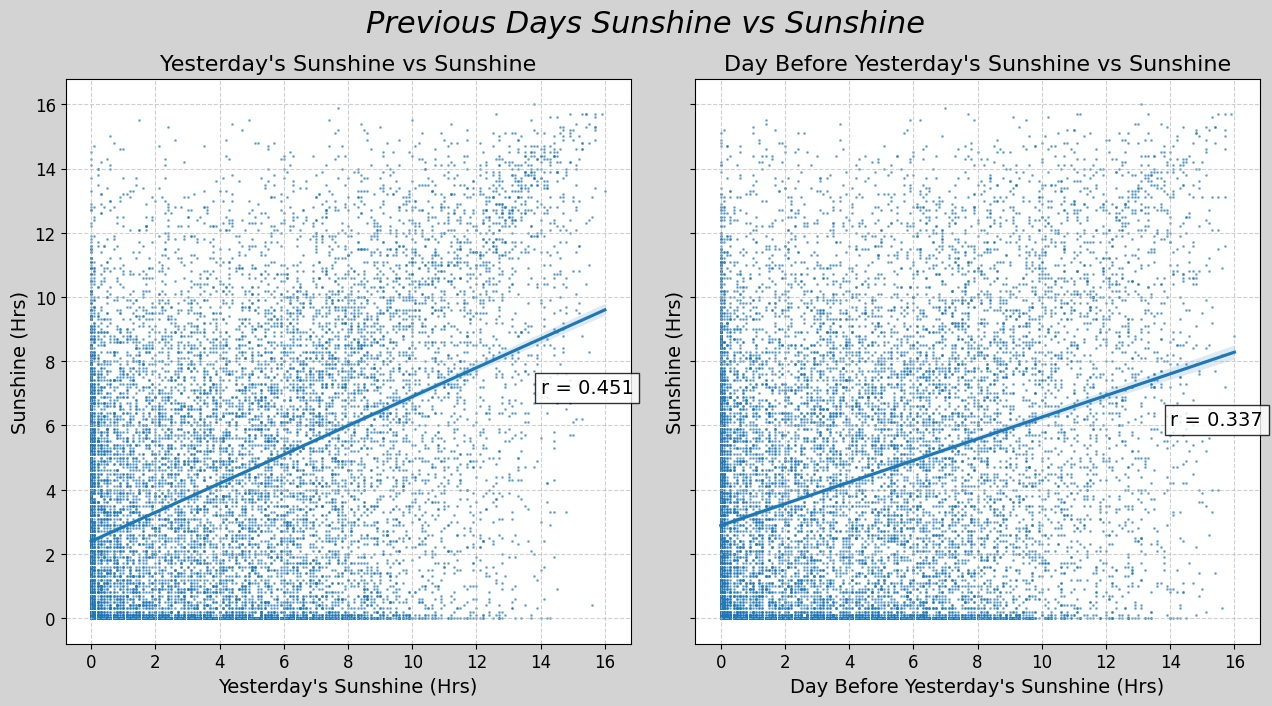

In [5]:
X = df.drop(columns=['sunshine'])
y = df['sunshine']
X_lag, y_lag = add_lag_features(X, y)
lag_df = X_lag.copy()
lag_df['sunshine'] = y_lag

fig = plot_lag_scatter(lag_df)
fig.savefig(f'{FIGURES}/lag_scatter.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Cloud cover vs sunshine, by season

A season column was added in src/features.py module.

Cloud cover is measured in integers from 0(clear) to 8 (overcast), in eighths of sky covered, also known as "oktas".

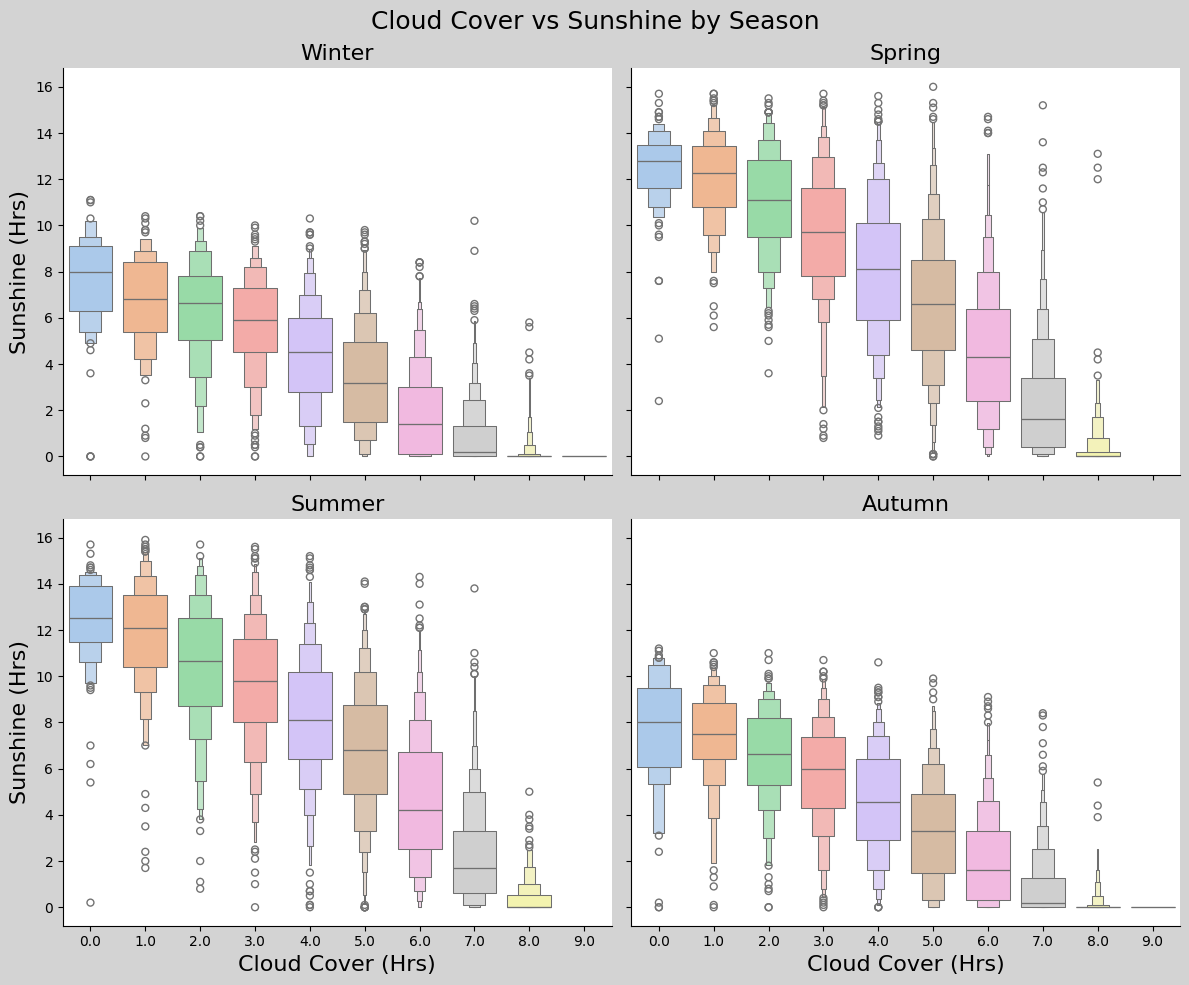

In [6]:
df_seasoned = add_season(df)
season_col = df_seasoned[['Spring', 'Summer', 'Autumn', 'Winter']].idxmax(axis=1)
df_with_season = df.assign(Season=season_col)

fig = plot_cloud_cover(df_with_season)
fig.savefig(f'{FIGURES}/cloud_cover.png', dpi=120, bbox_inches='tight')
plt.show()

- Strong negative relationship with sunshine expected and observed. 

- **Interestingly**, the plot shows the gradient of this relationship being roughly consistent with all seasons but the intercept changing. The plot has highlighted the seasonal effect of the length of the days changing.

*Note* - mistake made initally: footprints left when data wrangling inconsiderately.  
On first pass of data exploration I found 19 values of cloud_cover with 5.26... Initially I suspected float corrupted data, but the fact that there were also 19 missing values of cloud_cover was a red flag. I then realised that I made the mistake of running a global SimpleImputer with a mean strategy over the whole frame, transforming the missing values. 

This just furthers the importance of using pipelines in my work. The modelling notebook will use a pipeline with a cleaned dataset that will include the 19 missing values for cloud cover.

Plot made with the mistake of 19 float cloud_cover values, that made me catch my mistake below.

![Cloud cover vs sunshine, original script](../legacy/Output_Plots/cloudcover_vs_sunshine.png)

## 8. Global radiation vs sunshine, by season

- Global radiation, measured in W/m<sup>2</sup>, in other words, the total electromagnetic energy from the sun hitting the surface of the sensor, is unsuprisingly the best predictor of the amount of sunshine. 

- Linear relationship expected and observed. Slope changes slighly across seasons due to the length of the days changing.


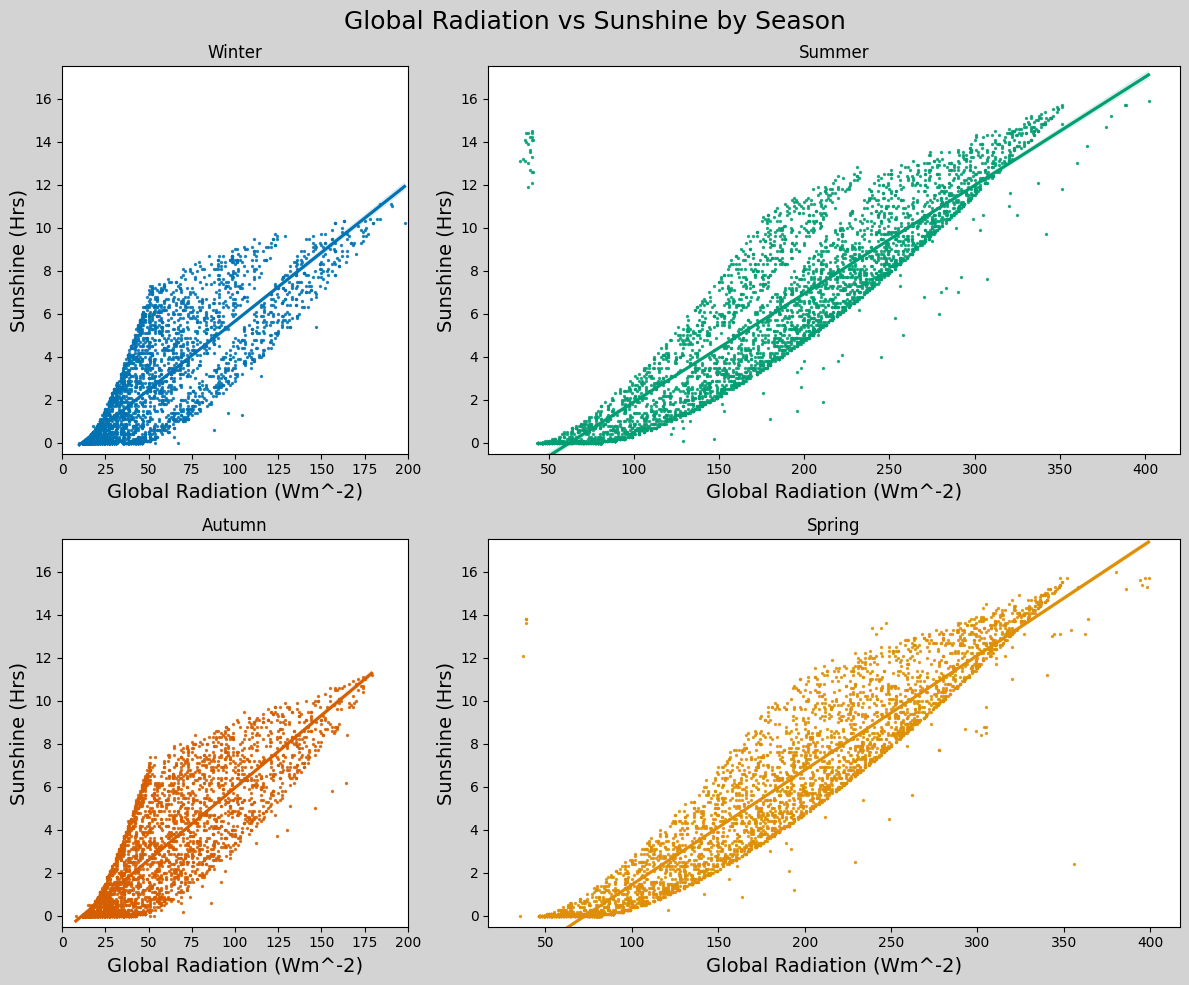

In [7]:
fig = plot_global_radiation(df_with_season)
fig.savefig(f'{FIGURES}/global_radiation.png', dpi=120, bbox_inches='tight')
plt.show()


- Artifacts in the Spring & Summer seasons where the sunshine is between 12-15 hours with global radiation at only two quantised values.
    - One reason I can think of is that on those days a shadow was cast over the sensor for whatever reason, construction, maintenance etc.
    - Otherwise it could be a fallback value, if there was so much sunshine that day that the sensor failed and fell back to a 50 W/m<sup>2</sup> reading
    - 50 W/m<sup>2</sup> is the zero reading after all, the value the sensor outputs when there is zero sunshine, so the explanation that the sensor failed that day and that 50 W/m<sup>2</sup> is simply the reading of the base voltage running across the sensor makes a lot of sense.

Lets look at these values more closely.

In [8]:
mask = (df['sunshine'] >= 9) & (df['global_radiation'] < 80)

artifact = (df.loc[mask, 
                   ['date', 'sunshine', 'global_radiation', 'cloud_cover']
                   ].sort_values('date').reset_index(drop=True))                                                 

artifact

,date,sunshine,global_radiation,cloud_cover
0,2016-07-18,14.4,38.0,0.0
1,2016-07-19,14.4,37.0,0.0
2,2017-07-02,12.6,41.0,3.0
3,2017-07-05,13.9,38.0,0.0
4,2018-05-19,13.8,39.0,1.0
5,2018-05-20,13.8,39.0,0.0
6,2018-05-22,13.6,39.0,2.0
7,2018-06-11,12.1,37.0,3.0
8,2018-06-21,12.1,40.0,2.0
9,2018-06-22,14.1,41.0,0.0


All values are from May to July with very low cloud cover. Certainly a sensor failure.

**Decision**: These values should be dropped in the cleaning process.

- Are there negative values for sunshine? why does the line of best fit extend before zero? lets check.

In [9]:
print(df['sunshine'].min())  
print("Nope")

0.0
Nope


## 9. Pressure distribution by season

- Exemplary collection of gaussian distributions.

- This is reasurring because it means that the dataset is large enough for the Central Limit Theorem to show up.

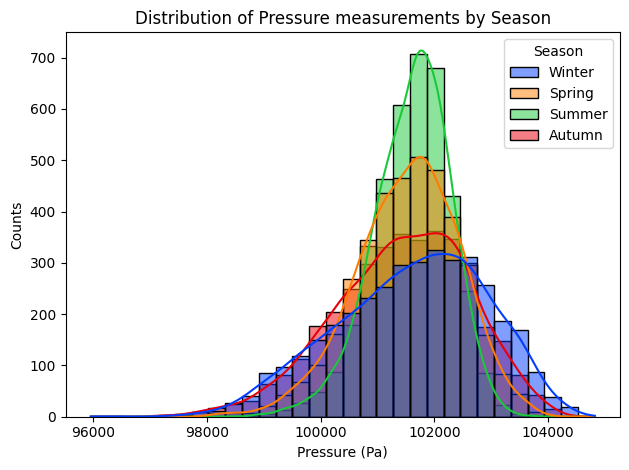

In [10]:
fig = plot_pressure_histogram(df_with_season)
fig.savefig(f'{FIGURES}/pressure_histogram.png', dpi=120, bbox_inches='tight')
plt.show()

## 10. Summary

- Global radiation, cloud cover and sunshine lag all expected to be strong. Weather is a multi variable non linear system, Machine Learning models will spot the indirect correlations.

- Data cleaning actions:
    - snow_depth missing values imputed to zero in non winter dates, and backfilled in winter.
    - global_radiation artifacting at high sunshine, 50 W/m<sup>2</sup> need to be removed.
    - Other missing values handled with SimpleImputer in pipeline.

- Will be interesting to experiment with feature engineering.